**Synaptic biophysics** practical course Simulating Synapses day 4

*Simulation of AMPA and NMDA synaptic conductances in a LIF neuron, including voltage-dependent block by Mg2+ of NMDA*

Poisson or bursty input trains.

Based on the simulation from Neuromatch (Richard Naud): 
https://instructor.compneuro.neuromatch.io/tutorials/W2D3_BiologicalNeuronModels/instructor/W2D3_Tutorial3.html

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

Plotting Functions

In [2]:
# show the timing / density of the input trains
def my_illus_trains(pars, train1, train2, show=False):
  """
  Illustration of the spike train

  Args:
    pars  : parameters dictionary
    train1 : spike train
    train2 : spike train

  Returns:
    nothing
  """
  
  plt.subplot(2,2,3)

  #from GPT5

  #eventplot takes a list of spike indices for each train. Multiply by dt to convert to spike times
  positions1 = [list(np.nonzero(row)[0]*pars['dt']) for row in train1]
  positions2 = [list(np.nonzero(row)[0]*pars['dt']) for row in train2]
    
  plt.eventplot(positions1, color='g', lineoffsets = 1)
  plt.eventplot(positions2, color='r', lineoffsets = -1)
    
  plt.xlabel('Time (ms)')
  plt.ylabel('Inputs (green E, red I)')
  #plt.legend(loc=[.8, 0.68])
  
  if show:
    plt.show()

In [3]:
def my_illus_G_NMDA (t_ssR, impulse_ssR, train, G_NMDA_unblocked, G_NMDA_true,  show=False):
    """
    Illustration of the NMDA excitatory synaptic conductances.

    Args:
        t_ssR            : time array of the slow synaptic response
        impulse_ssR      : slow impulse response of the synapse 
        train            : sum of excitatory neuron inputs
        G_NMDA_unblocked : the 'free' NMDA conductance (if there were no block)
        G_NMDA_true      : the NMDA conductance with block taken into account
        show             : reveal the plot already (default False)

    Returns:
        nothing
    """
    
    plt.figure(figsize=(12, 9))
    plt.subplot(2,2,1)

    plt.plot(t_ssR, impulse_ssR, 'r', lw=1.,
           label='NMDA synaptic impulse conductance', zorder=2)

    plt.xlabel('Time (ms)')
    plt.ylabel('G (nS)')
    plt.legend(loc=[0.3, 0.68])
  
    plt.subplot(2,2,2)
    plt.plot(pars['range_t'], G_NMDA_unblocked, 'black', lw=1.,
           label='free NMDA synaptic conductance \n in response to trains', zorder=2)   #truncate at the end of the train 
    plt.plot(pars['range_t'], G_NMDA_true, 'blue', lw=1.,
           label='true NMDA synaptic conductance', zorder=2)   #truncate at the end of the train 
    plt.plot(pars['range_t'], -train, 'green', lw=1.,
           label='Sum of excitatory input trains', zorder=2)
    plt.xlabel('Time (ms)')
    plt.ylabel('G (nS)')
    plt.legend(loc=[1.1, 0.68])
    
    if show:
        plt.show()


In [4]:
def my_illus_LIFSYN(pars, v_fmp, v, show=False):
  """
  Illustration of Free Membrane Potential (FMP, if there were no spikes, just the input) and membrane voltage with spikes
  plot of membrane voltage and FMP, alongside with the spiking threshold and the mean FMP (dashed lines)

  Args:
    pars  : parameters dictionary
    v_fmp : free membrane potential, mV
    v     : membrane voltage, mV

  Returns:
    nothing
  """

  #plt.figure(figsize=(7, 5))
  plt.subplot(2,2,4)
  plt.plot(pars['range_t'], v_fmp, 'r', lw=1.,
           label='Free mem. pot.', zorder=2)
  plt.plot(pars['range_t'], v, 'b', lw=1.,
           label='True mem. pot', zorder=1, alpha=0.7)
  plt.axhline(pars['V_th'], 0, 1, color='k', lw=2., ls='--',
              label='Spike Threshold', zorder=1)
  plt.axhline(np.mean(v_fmp), 0, 1, color='r', lw=2., ls='--',
              label='Mean Free Mem. Pot.', zorder=1)
  plt.xlabel('Time (ms)')
  plt.ylabel('V (mV)')
  plt.legend(loc=[1.1, 0.68])
  
  if show:
      plt.show()

In [5]:
   
def burst_train(max_time, rate, burst_interval=300, burst_isi=25, min_isi=5, noise=2):
    """
    modified from https://github.com/neurord/synth_trains/blob/master/spike_train_utils.py
    method5 from Corr_plot_v2_1.py 
    use exponential distribution twice, generates a single train
    ISI has high peak and long tailed ISI distribution.  Exponentially distributed bursts.
    good method for bursty data:  
    higher intertrain isi produces lower CV. itisi=0.1 --> 1.0; iti=0.3-->0.7; itisi=0.03-->1.4-1.6
    lower noise = higher CV

    Args:
        max_time       : [ms] duration of the train
        rate           : [Hz] mean firing rate
        burst_interval : [ms] mean interval
        burst_isi      : [ms] mean inter-spike-interval in the burst
        min_isi        : [ms] minimum interspike interval 
        noise      

    Returns:
        A Numpy array of spike times
    """

    spike_times = []
    num_spikes_per_cell = int(max_time * rate / 1000)   #max time in ms
    timer = 0  
    
    while timer < max_time:
        
        # t is exponentially distributed interval between bursts
        # why not use intertrain isi
        # f(x; 1/beta) = 1/beta *exp(-x/beta),
        num_bursts_bar = max_time/burst_interval
        t = max(min_isi, np.random.exponential(burst_interval))
        timer += t
        
        # determine how many ISIs to generate within the burst - should be spikes_per_burst
        nI = max(2, np.random.geometric(num_bursts_bar / num_spikes_per_cell))
        
        # gaussian distribution of parameter used in exponential, mean = intertrain_isi, sigma = noise
        # double dose of noise 
        it_isi = burst_isi + np.random.randn(nI) * noise
        
        # replace any ISI lower than min_isi with min_isi
        it_isi = np.array([x if x > min_isi else min_isi for x in it_isi])
        
        # these ISIs are exponentially distributed within the bursts
        # could be a problem if it_isi=min_isi, which happens if noise too high
        isi_list = np.random.exponential(it_isi, size=nI)
        
        # place the spikes from the burst into the correct position
        burst_spike_times = np.cumsum(isi_list[isi_list > min_isi]) + timer
        
        # print('burst npre',n, 'npost', len(times[times < max_time] ))
        spike_times = np.append (np.array(spike_times), burst_spike_times)
        
        if spike_times.size > 0:
            timer = int(spike_times[-1])  
    
    #print ("Spikes: {0} vs expected {1}".format(len(spike_times), num_spikes_per_cell))    
    return spike_times

def Burst_trains(pars, rate, n, myseed=False):

    """
    generate matrix of trains x cells
    same arguments as the Poisson generator, for convenience
    modify the arguments in burst_train to get different statistics
    
    Args :  
    -pars       : parameter dictionary
    -rate       : firing rate [Hz]
    -n          : number of independent "bursty" trains
    -myseed     : random seed. int or Boolean
   
    Returns :   
    - burst_train_matrix: spike train Numpy matrix, ith row represents whether
                            there is a spike in ith spike train over time
                                (1 if spike, 0 otherwise)
    """
    
    dt, range_t = pars['dt'], pars['range_t']
    Lt = range_t.size
    #print (Lt)
    
    # set random seed
    if myseed:
        np.random.seed(seed=myseed)
    else:
        np.random.seed()

    # generate matrix of zeros
    burst_train_matrix = np.zeros((n, Lt))
    
    for cell in range(n):
        b = burst_train (Lt * dt, rate)
        digitised, _, _ = spikes_to_onehot(b)
        burst_train_matrix [cell,:] = digitised[:Lt]

    return burst_train_matrix
    
# from duck.ai GPT5
def spikes_to_onehot(spike_times, t_start=0.0, t_stop=None, dt=0.1):
    """
    Convert spike times to a 1-hot binary array.

    Args:
    - spike_times: 1D array-like of spike times (float). Can be unsorted.
    - t_start: start time (inclusive). Default 0.0.
    - t_stop: stop time (exclusive). If None, set to max(spike_times) + dt.
    - dt: bin width in same units as spike_times (default 0.001).

    Returns:
    - onehot: 1D numpy array of dtype=np.uint8 with length N_bins (0/1).
    - bin_edges: numpy array of length N_bins+1 of bin edges.
    - bin_centers: numpy array of length N_bins of bin centers.
    """
    spike_times = np.asarray(spike_times, dtype=float)
    if spike_times.size == 0 and t_stop is None:
        t_stop = t_start + dt
    if t_stop is None:
        t_stop = spike_times.max() + dt
    if t_stop <= t_start:
        raise ValueError("t_stop must be greater than t_start")

    # compute bins
    bin_edges = np.arange(t_start, t_stop + 1e-12, dt)
    # ensure last edge >= t_stop
    if bin_edges[-1] < t_stop:
        bin_edges = np.append(bin_edges, t_stop)
    N_bins = len(bin_edges) - 1
    # histogram counts
    counts, _ = np.histogram(spike_times, bins=bin_edges)
    # convert to 0/1 (1 if any spike in bin)
    onehot = (counts > 0).astype(np.uint8)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    
    return onehot, bin_edges, bin_centers

In [6]:
def Poisson_generator(pars, rate, n, myseed=False):
  """
  Generates poisson trains

  Args:
    pars       : parameter dictionary
    rate       : noise amplitute [Hz]
    n          : number of indepndent Poisson trains
    myseed     : random seed. int or Boolean

  Returns:
    poisson_train : spike train matrix, ith row represents whether
                      there is a spike in ith spike train over time
                      (1 if spike, 0 otherwise)
  """

  # Retrieve simulation parameters
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # set random seed
  if myseed:
      np.random.seed(seed=myseed)
  else:
      np.random.seed()

  # generate matrix of uniformly distributed random variables
  u_rand = np.random.rand(n, Lt)

  # generate Poisson train
  poisson_train = 1. * (u_rand < rate * (dt / 1000.))

  return poisson_train


Parameters for the simulation of LIF neuron

In [7]:
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = -50.    # spike threshold [mV] - was -55 mV
  pars['V_reset'] = -75. # reset potential [mV]
  pars['tau_m'] = 10.    # membrane time constant [ms]
  pars['g_L'] = 10.      # leak conductance [nS]
  pars['V_init'] = -65.  # initial potential [mV]
  pars['E_L'] = -75.     # leak reversal potential [mV]
  pars['tref'] = 2.      # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 4000.  # Total duration of simulation [ms]
  pars['dt'] = .1   # Simulation time step [ms]

  ### external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized time points [ms]

  return pars

In [8]:
# @markdown Execute this cell to get a function for conductance-based LIF neuron (run_LIF_cond)

def run_LIF_cond(pars, I_inj, pre_spike_train_ex, pre_spike_train_in, first_run=True):
  """
  Conductance-based LIF dynamics

  Args:
    pars               : parameter dictionary
    I_inj              : injected current [pA]. The injected current here
                         can be a value or an array
    pre_spike_train_ex : spike train input from presynaptic excitatory neuron
    pre_spike_train_in : spike train input from presynaptic inhibitory neuron

  Returns:
    rec_spikes         : spike times
    rec_v              : membrane potential
    gE                 : postsynaptic excitatory conductance
    gI                 : postsynaptic inhibitory conductance

  """

  # Retrieve parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, E_L = pars['V_init'], pars['E_L']
  gE_bar, gI_bar = pars['gE_bar'], pars['gI_bar']
  VE, VI = pars['VE'], pars['VI']
  tau_syn_I = pars['tau_syn_I']
  taus_syn_E = pars['taus_syn_E']
  amps_syn_NMDA = pars['amps_syn_NMDA']
  amps_syn_AMPA = pars['amps_syn_AMPA']
  tref = pars['tref']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # Initialize
  tr = 0.
  v = np.zeros(Lt)
  v[0] = V_init
  gE = np.zeros(Lt)
  gI = np.zeros(Lt)
  Iinj = I_inj * np.ones(Lt)  # ensure Iinj has length Lt

  if pre_spike_train_ex.max() == 0:        #no spikes
    pre_spike_train_ex_total = np.zeros(Lt)
  else:
    pre_spike_train_ex_total = pre_spike_train_ex.sum(axis=0) * np.ones(Lt)

  if pre_spike_train_in.max() == 0:
    pre_spike_train_in_total = np.zeros(Lt)
  else:
    pre_spike_train_in_total = pre_spike_train_in.sum(axis=0) * np.ones(Lt)

  # calculate the shape of the slow synaptic impulse response (kernel). 
  # these should be set as parameters
  t_AMPA, g_AMPA = slowConductance(taus_syn_E, amps_syn_AMPA, dt=0.1) 
  t_NMDA, g_NMDA = slowConductance(taus_syn_E, amps_syn_NMDA, dt=0.1)   
  
  # convolve globally, not per synapse.
  
  G_NMDA = np.convolve(pre_spike_train_ex_total, g_NMDA) * pars['gE_bar']
  G_AMPA = np.convolve(pre_spike_train_ex_total, g_AMPA) * pars['gE_bar']
  
  
  
  # simulation
  rec_spikes = []  # recording spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset        # during refractory period, the membrane potential is reset
      tr = tr - 1
    elif v[it] >= V_th:      # record spike event
      rec_spikes.append(it)
      v[it] = V_reset        # reset voltage during spike
      #v[it] = 0.01          # alternatively: DEPOLARISE to 10 mV for SPIKE, to allow some NMDA unblock
      tr = tref / dt

    # update the synaptic conductance
    # for slow excitatory conductances this is more sophisticated, we do not need to update gE for each step
    # gE was created in full above
    # first term is the decrement, second term is the instant peak of any synaptic input
    
    # fast synaptic currents  
    #gE[it + 1] = gE[it] - (dt / tau_syn_E) * gE[it] + gE_bar * pre_spike_train_ex_total[it + 1]
    gI[it + 1] = gI[it] - (dt / tau_syn_I) * gI[it] + gI_bar * pre_spike_train_in_total[it + 1]

    # calculate the increment of the membrane potential
    dv = (dt / tau_m) * (-(v[it] - E_L) \
                         - (G_NMDA[it + 1] / g_L) * (v[it] - VE) * Block (v[it]) \
                         - (G_AMPA[it + 1] / g_L) * (v[it] - VE)  \
                         - (gI[it + 1] / g_L) * (v[it] - VI) + Iinj[it] / g_L)

    # update membrane potential
    v[it+1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  #show the NMDA conductance, with and without block   
  if first_run:
      my_illus_G_NMDA (t_NMDA, g_NMDA, pre_spike_train_ex_total, G_NMDA[:v.size], G_NMDA[:v.size] * Block(v), show=False)

  return v, rec_spikes, gE, gI


In [9]:
def slowConductance (taus=[1,1,1], amps=[0,0,0], dt=0.1):
    # provide a digitised synaptic current for convolution
    # the shape of the synaptic current is defined by 3 exponential decay components
    # amps should add up to 1 for a normalised response
    # use a negative amplitude for slow rise
    
    # returns Zero by default
    # returns the time array and the corresponding impulse response array

    # find the largest time constant
    longest = max(taus)

    # make an array long enough take 5* longest tau to get 99% of decay
    t_G_Slow = np.arange(0, 5 * longest, step=dt)

    # digitise the impulse response
    G_slow = amps[0] * np.exp(-t_G_Slow/taus[0]) + amps[1] * np.exp(-t_G_Slow/taus[1]) + amps[2] * np.exp(-t_G_Slow/taus[2])
    
    return t_G_Slow, G_slow

In [17]:
def Block (V):
    # calculate fraction of *unblocked* NMDA receptors at a given voltage
    # no kinetic consideration to the unblock, purely equilibrium level. 
    # that means both block and unblock are instant (not physiological)
    # B(V) is the nonlinear Mg2+ block, with [Mg2+]0 = 1 mM, k0 = 3.57 & 1/V0 = −0.062 , for normal operating conditions (Jahr & Stevens, 1990). 
    # V in millivolts, works with scalar or vector input
    
    c_Mg = 1 # in millimolar 1
    k_0 = 30  #3.57
    inv_v0 = -0.062 #-0.062

    c__k = c_Mg/k_0

    return 1/(1+ c__k * np.exp(inv_v0 * V))
    

Main Code

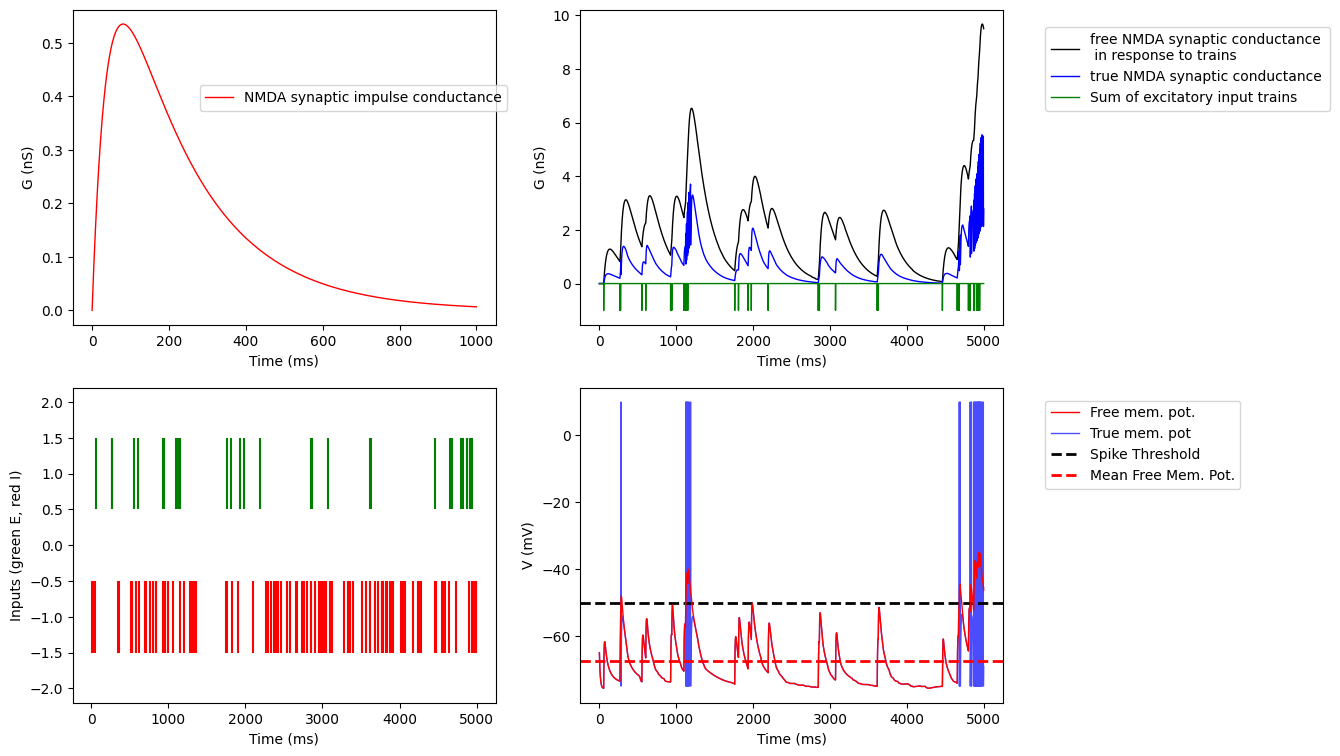

In [ ]:
# Get default parameters
pars = default_pars(T=5000.)

# Add parameters
# excitatory
pars['gE_bar'] = 2.4    # [nS] was 2.4   1 receptor is 25 pS both AMPA and NMDA the same size
pars['VE'] = 0.         # [mV] excitatory reversal potential
pars['taus_syn_E'] = [10., 40., 200.]  # [ms]
pars['amps_syn_NMDA'] = [0, -1, 1] # unitless - slow rise and slow decay
pars['amps_syn_AMPA'] = [1, 1, 0] # unitless - single fast decay
#pars['amps_syn_E'] = [.5, 0, .5] # unitless - fast decay and slow decay

# inhibitory
pars['gI_bar'] = .6      # [nS]
pars['VI'] = -80.       # [mV] inhibitory reversal potential
pars['tau_syn_I'] = 100.  # [ms]

pars['N_I'] = 1         # Number of inhibitory synapses
pars['N_E'] = 1          # Number of excitatory synapses
pars['r_I'] = 20         # Rate of inhibitory input [Hz]
pars['r_E'] = 10         # Number of excitatory input [Hz]

# Generate presynaptic spike trains
#pre_spike_train_ex = Poisson_generator(pars, pars['r_E'], n=pars['N_E'])
pre_spike_train_ex = Burst_trains(pars, pars['r_E'], n=pars['N_E'])
pre_spike_train_in = Poisson_generator(pars, pars['r_I'], n=pars['N_I'])

# Simulate conductance-based LIF model
# no injected current
v, rec_spikes, gE, gI = run_LIF_cond(pars, 0, pre_spike_train_ex,
                                     pre_spike_train_in)

# Show spikes more clearly by setting voltage high
dt, range_t = pars['dt'], pars['range_t']
if rec_spikes.size:
  sp_num = (rec_spikes / dt).astype(int) - 1
  v[sp_num] = 10   # draw nicer spikes


# Temporarily remove the threshold 
original_V_th = pars['V_th'] 
pars['V_th'] = 1e3

# Calculate FMP
v_fmp, _, _, _ = run_LIF_cond(pars, 0, pre_spike_train_ex, pre_spike_train_in, first_run=False)

#reset to original threshold for display
pars['V_th'] = original_V_th

# train inputs as a separate graph
my_illus_trains(pars, pre_spike_train_ex, pre_spike_train_in)

#with plt.xkcd():
my_illus_LIFSYN(pars, v_fmp, v)

plt.show()
# the block reveals the AMPA conductance -> what leads to the spike is AMPA not NMDA
# most of the current is calcium not Sodium -> ions that permeable slowly kinda blocks the ion channels.
# the ions permeable differently fast, and NMDA prefers calcium

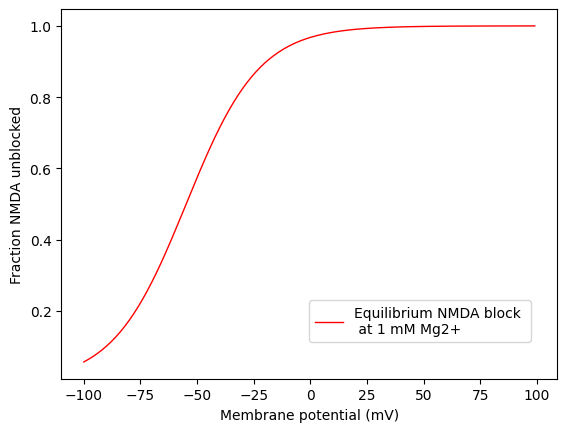

In [22]:
vm = np.arange (-100,100) # in mV

plt.plot(vm, Block(vm), 'r', lw=1.,
           label='Equilibrium NMDA block \n at 1 mM Mg2+', zorder=2)

plt.xlabel('Membrane potential (mV)')
plt.ylabel('Fraction NMDA unblocked')
plt.legend(loc=[0.5, 0.1])

plt.show()
# is a langmuir adsorption model
# if i just use NMDA,(google: reverse potential)

![title](img/NMDA_block.png)
*from Jahr and Stevens 1990*